In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN,Dropout
from tensorflow.keras.optimizers import Adam
from datetime import date

In [2]:
import yfinance as yf
today = date.today()

# Ask the user to input the ticker symbol
ticker_symbol = input("Enter the ticker symbol of the cryptocurrency: ")
start_date ='2020-01-01'
end_date=date.today()
dates = pd.date_range(start_date, end_date.today())
# Fetch cryptocurrency data
df = yf.download(ticker_symbol, start=start_date, end=date.today())

# Display the fetched data

df.reset_index(inplace=True)

df.head()



[*********************100%%**********************]  1 of 1 completed


,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,7200.174316,18565664997
1,2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,6985.470215,20802083465
2,2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,7344.884277,28111481032
3,2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,7410.656738,18444271275
4,2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,7411.317383,19725074095


In [3]:
data = df["Close"].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [4]:
train_size = int(len(scaled_data) * 0.8)
test_size = len(scaled_data) - train_size
train_data, test_data = scaled_data[0:train_size, :], scaled_data[train_size:len(scaled_data), :]

In [5]:
def create_dataset(dataset, target, time_step=1):
    X, y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        y.append(target[i + time_step])
    return np.array(X), np.array(y)

In [6]:
time_step = 100
X_train, y_train = create_dataset(train_data, train_data[:, 0], time_step)
X_test, y_test = create_dataset(test_data, test_data[:, 0], time_step)

In [7]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)


In [8]:
if len(X_test.shape) == 2:
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    

In [9]:
model = Sequential()
model.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(SimpleRNN(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))


c:\Users\shrya\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer=Adam(learning_rate=0.001), loss="mean_squared_error", metrics=["accuracy"])


In [11]:
model.fit(X_train, y_train, epochs=50, batch_size=64)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.0000e+00 - loss: 0.5677
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.0000e+00 - loss: 0.1246
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.0000e+00 - loss: 0.0866
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.0000e+00 - loss: 0.0695
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0556
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.0000e+00 - loss: 0.0477
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.0000e+00 - loss: 0.0360
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0328
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.0000e+00 - loss: 0.0245
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.0000e+00 - loss: 0.0232
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0222
Epoch 12/50
19/19

In [12]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
tests = scaler.inverse_transform(test_data.reshape(-1, 1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step


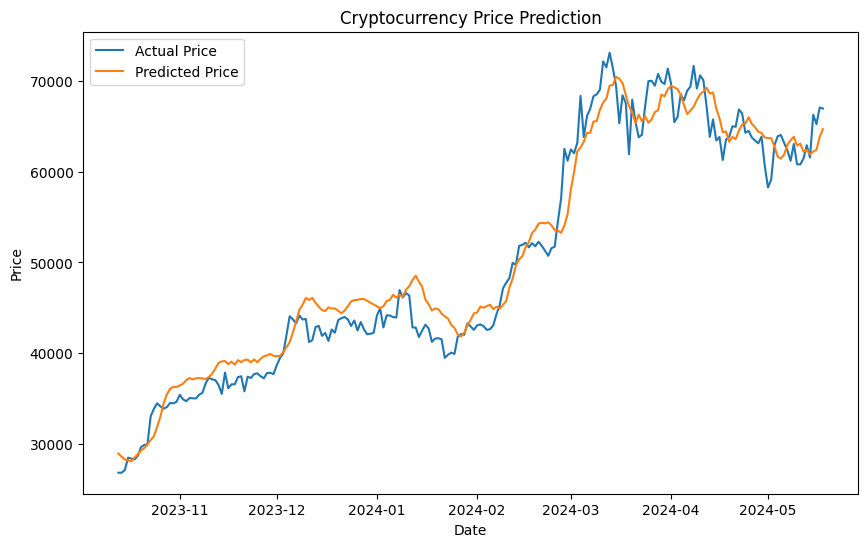

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(df["Date"][-len(predictions):], df["Close"][-len(predictions):], label="Actual Price")
plt.plot(df["Date"][-len(predictions):], predictions, label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Cryptocurrency Price Prediction")
plt.legend()
plt.show()




In [14]:

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 100, 50)        │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100, 50)        │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,255 (149.44 KB)

 Trainable params: 12,751 (49.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,504 (99.63 KB)

In [15]:

# pas_100_days = train_data.tail(100)

# train_data= np.concatenate(train_data[:-100], test_data)

train_data=pd.DataFrame({'Close': train_data.tolist()})

In [16]:
pas_100_days = train_data.tail(100)

In [17]:
len(test_data)

320

In [18]:
len(pas_100_days)

100

In [19]:


test_data=pd.DataFrame({'Close': test_data.tolist()})


In [20]:
test_data = pd.concat([pas_100_days, test_data], ignore_index=True, axis=0)
test_data

,Close
0,[0.3380212201980182]
1,[0.32547669829837567]
2,[0.3273594920368162]
3,[0.34322012240252564]
4,[0.3385972128544918]
...,...
415,[0.8307113222558478]
416,[0.899930459073488]
417,[0.8847216951417713]
418,[0.9114464124169643]


In [21]:
len(test_data)

420

In [22]:
test_data.dropna(inplace=True)

In [23]:

test_data['Close'] = test_data['Close'].apply(lambda x: x[0])


In [24]:

test_data

,Close
0,0.338021
1,0.325477
2,0.327359
3,0.343220
4,0.338597
...,...
415,0.830711
416,0.899930
417,0.884722
418,0.911446


In [25]:
data_test_scale  =  scaler.fit_transform(test_data)



In [26]:
x = []
y = []

for i in range(100, data_test_scale.shape[0]):
    x.append(data_test_scale[i-100:i])
    y.append(data_test_scale[i,0])
x, y = np.array(x), np.array(y)
len(x[0])

100

In [27]:
y_predict = model.predict(x)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [28]:
scale =1/scaler.scale_

In [29]:
y_predict = y_predict*scale

In [30]:
y = y*scale

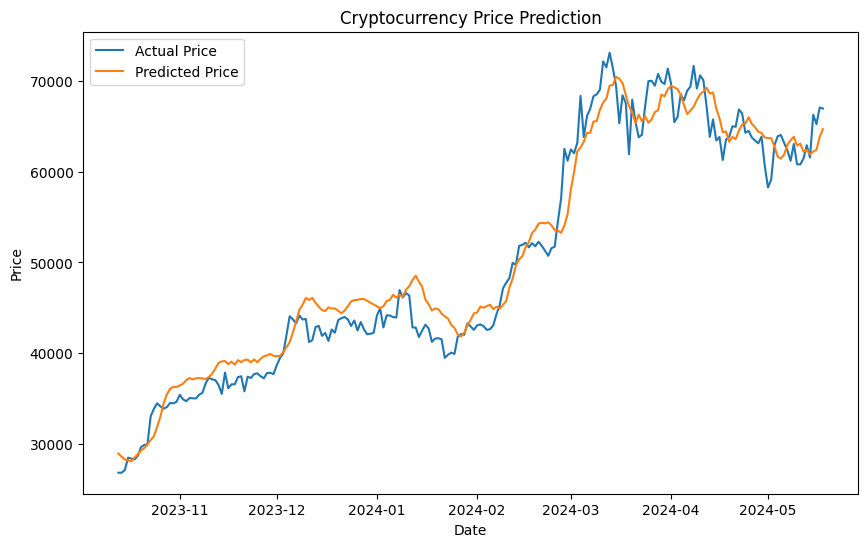

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(df["Date"][-len(predictions):], df["Close"][-len(predictions):], label="Actual Price")
plt.plot(df["Date"][-len(predictions):], predictions, label="Predicted Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Cryptocurrency Price Prediction")
plt.legend()
plt.show()


In [32]:
model.save('CryptoSphere.keras')